# Lennard-Jones, but as a hardware engineer would build it

`dgs.lennard_jones` evaluates $V(r) = 4\varepsilon[(\sigma/r)^{12} - (\sigma/r)^6]$
directly -- two real `pow()` calls per pair, every timestep, for every pair
of atoms. Real molecular-dynamics codes (GROMACS, LAMMPS) and
special-purpose MD hardware (D.E. Shaw's Anton machines) don't do that at
scale: they precompute the function on a table and interpolate, exactly
the way a digital-logic lookup table works.

This notebook builds that table, checks that it actually converges to the
exact answer (not just "runs"), and asks the real hardware-design
question: how many bits of fixed-point table storage does a given
accuracy cost?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt

from dgs.lennard_jones import lj_potential, lj_force_magnitude, hex_cluster, pair_forces
from dgs.lennard_jones_lut import (
    build_lj_lut, lut_lookup, verify_lut_converges, quantize_table,
    lut_quantization_error, pair_forces_lut,
)
print("loaded dgs.lennard_jones, dgs.lennard_jones_lut")

loaded dgs.lennard_jones, dgs.lennard_jones_lut


## Part 1 -- the actual trick: index by $r^2$, not $r$

A pairwise distance in any MD loop comes from
$r^2 = dx^2+dy^2+dz^2$ -- you already have $r^2$ for free. Building the
table on a uniform $r^2$ grid means the whole force evaluation never
needs a `sqrt` at all, and the force itself is tabulated as $F(r)/r$ so
applying it is just `(F(r)/r) * (x_i - x_j)` -- no division by $r$
either.

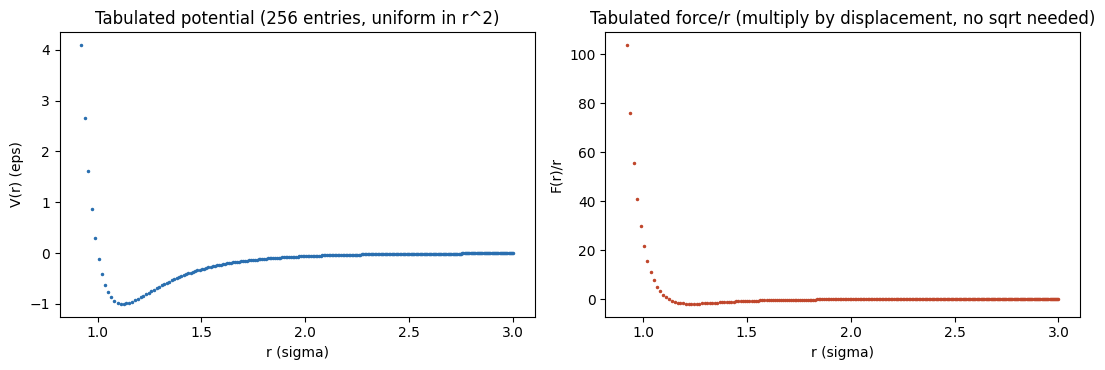

In [2]:
r2_grid, V_table, FoverR_table = build_lj_lut(r2_min=0.85, r2_max=9.0, n_entries=256)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(np.sqrt(r2_grid), V_table, '.', ms=3, color='#2a6fb0')
axes[0].set_xlabel('r (sigma)'); axes[0].set_ylabel('V(r) (eps)')
axes[0].set_title('Tabulated potential (256 entries, uniform in r^2)')
axes[1].plot(np.sqrt(r2_grid), FoverR_table, '.', ms=3, color='#c0472c')
axes[1].set_xlabel('r (sigma)'); axes[1].set_ylabel('F(r)/r')
axes[1].set_title('Tabulated force/r (multiply by displacement, no sqrt needed)')
fig.tight_layout()
plt.show()

## Part 2 -- does the LUT actually converge?

The whole justification for a LUT is that it approximates the exact
evaluation well enough, cheaply. `verify_lut_converges` checks that
directly: RMS error between LUT-interpolated and exact `lj_potential` at
random test points, as a function of table size.

n_entries=   16   RMS error vs. exact = 5.534e-01
n_entries=   64   RMS error vs. exact = 6.321e-02
n_entries=  256   RMS error vs. exact = 4.902e-03
n_entries= 1024   RMS error vs. exact = 2.503e-04
n_entries= 4096   RMS error vs. exact = 1.571e-05
monotonically improving: True


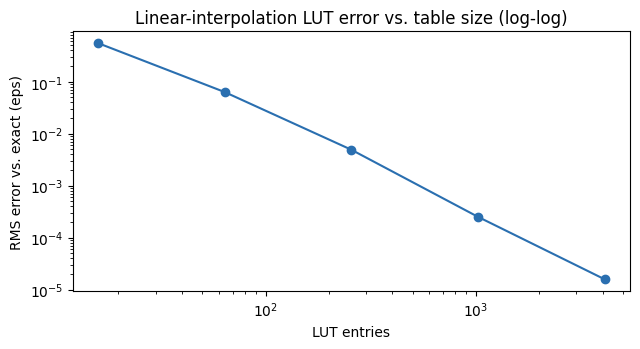

In [3]:
conv = verify_lut_converges(n_entries_list=(16, 64, 256, 1024, 4096))
for n, err in zip(conv['n_entries'], conv['rms_error']):
    print(f"n_entries={n:5d}   RMS error vs. exact = {err:.3e}")
print(f"monotonically improving: {conv['monotonically_improving']}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.loglog(conv['n_entries'], conv['rms_error'], 'o-', color='#2a6fb0')
ax.set_xlabel('LUT entries'); ax.set_ylabel('RMS error vs. exact (eps)')
ax.set_title('Linear-interpolation LUT error vs. table size (log-log)')
fig.tight_layout()
plt.show()

Roughly a straight line on log-log axes: linear interpolation converges
like $O(\text{step}^2)$, so doubling the table size should cut the error
by about 4x -- check the ratios above against that.

## Part 3 -- the real hardware question: how many bits?

A LUT living in FPGA/ASIC block RAM is finite-width fixed-point memory,
not `float64`. `quantize_table` simulates storing the potential table at
`n_bits` of precision; `lut_quantization_error` sweeps bit width and
measures the RMS error quantization ALONE introduces (table size held
fixed, at 256 entries).

table dynamic range: 5.0924 eps

 4-bit fixed-point:  RMS quantization error = 7.305e-02
 6-bit fixed-point:  RMS quantization error = 2.030e-02
 8-bit fixed-point:  RMS quantization error = 6.034e-03
10-bit fixed-point:  RMS quantization error = 1.456e-03
12-bit fixed-point:  RMS quantization error = 3.639e-04
16-bit fixed-point:  RMS quantization error = 2.317e-05
24-bit fixed-point:  RMS quantization error = 8.587e-08


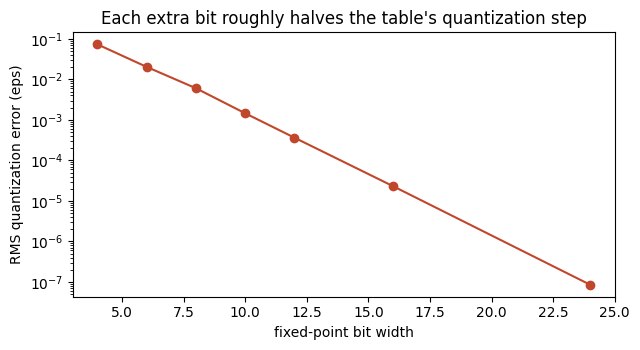

In [4]:
quant = lut_quantization_error(n_entries=256, n_bits_list=(4, 6, 8, 10, 12, 16, 24))
print(f"table dynamic range: {quant['table_range']:.4f} eps\n")
for nb_, err in zip(quant['n_bits'], quant['rms_error']):
    print(f"{nb_:2d}-bit fixed-point:  RMS quantization error = {err:.3e}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.semilogy(quant['n_bits'], quant['rms_error'], 'o-', color='#c0472c')
ax.set_xlabel('fixed-point bit width'); ax.set_ylabel('RMS quantization error (eps)')
ax.set_title('Each extra bit roughly halves the table\'s quantization step')
fig.tight_layout()
plt.show()

## Part 4 -- drop-in replacement: does it actually work in an MD loop?

`pair_forces_lut` has the exact same contract as
`dgs.lennard_jones.pair_forces` -- same inputs, same
`(forces, potential_energy)` return -- but every pairwise evaluation is a
table lookup instead of a `pow()` call. Run it on the same hexagonal
cluster used elsewhere in this repo's Lennard-Jones work and compare
directly against the exact evaluation.

In [5]:
pos = hex_cluster(n_rings=1)
F_exact, U_exact = pair_forces(pos)

r2_grid_fine, V_table_fine, FoverR_fine = build_lj_lut(r2_min=0.7, r2_max=9.0, n_entries=512)
F_lut, U_lut = pair_forces_lut(pos, r2_grid_fine, FoverR_fine, V_table_fine)

print(f"exact  U = {U_exact:.6f} eps")
print(f"LUT    U = {U_lut:.6f} eps   (diff {abs(U_exact-U_lut):.2e})")
print(f"max force-component error: {np.max(np.abs(F_exact - F_lut)):.2e}  (512-entry LUT)")

exact  U = -12.529232 eps
LUT    U = -12.524781 eps   (diff 4.45e-03)
max force-component error: 1.59e-02  (512-entry LUT)


## Summary

| | Exact evaluation | LUT (this notebook) |
|---|---|---|
| Per-pair cost | 2x `pow()` (12th and 6th power) | 1x table lookup + linear blend |
| Needs `sqrt`? | Yes (for the force direction) | No -- everything indexed by $r^2$ |
| Storage | None (recomputed every time) | One table in memory (or block RAM) |
| Accuracy knob | N/A (always exact) | Table size (interpolation) AND bit width (quantization) |

Two independent knobs control accuracy -- table resolution and storage
bit width -- and both were checked here to actually converge/degrade the
way the underlying math predicts, not just assumed. That's the real
systems-engineering tradeoff behind every production MD code's inner
loop, and behind purpose-built MD hardware like Anton: spend memory and
lose a controlled, quantifiable amount of precision to avoid millions of
`pow()` calls per timestep.